# Tutorial: Monocle 2 trajectory inference with `monocle2-py`

This notebook walks through a complete trajectory analysis pipeline on the
**Paul et al. 2015 hematopoiesis** dataset (~2 700 mouse bone-marrow cells),
using the standalone `monocle2_py` package.

What we'll do:

1. Preprocess counts (size factors + dispersion)
2. Pick dispersion-selected ordering genes
3. Learn the DDRTree principal graph
4. Assign pseudotime + branch `State`
5. Find branch-point differentially expressed genes with BEAM


In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from monocle2_py import Monocle

adata = sc.datasets.paul15()           # 2 730 cells × 3 451 genes
print(adata)

  0%|          | 0.00/9.82M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 2730 × 3451
    obs: 'paul15_clusters'
    uns: 'iroot'


## 1–2. Preprocess and pick ordering genes

`preprocess()` runs size-factor estimation + dispersion fitting (matches
R Monocle 2's `estimateSizeFactors()` + `estimateDispersions()`).
`select_ordering_genes()` keeps the top-dispersion genes for trajectory
learning.

In [2]:
mono = Monocle(adata)
mono.preprocess().select_ordering_genes(max_genes=1000)
print(mono)
print(f"n ordering genes = {int(adata.var['use_for_ordering'].sum())}")

Monocle(2730 cells × 3451 genes)
  preprocessed: ✓
  ordering genes: 190
n ordering genes = 190


## 3. Learn the trajectory

`reduce_dimension()` runs DDRTree. The default is `method='fast'`, which
uses three mathematical identities (matmul re-ordering, XXT caching,
sparse-R truncation) to run ~3× faster than the R reference at
pseudotime correlation ≥ 0.99. Pass `method='exact'` for bit-for-bit
agreement with R.

In [3]:
import time
t0 = time.time()
mono.reduce_dimension(method='fast').order_cells()
print(f"DDRTree + orderCells: {time.time()-t0:.1f} s")
print(mono)

[monocle2_py] Using fast DDRTree (≈3× speed-up, pseudotime correlation with R ≥ 0.99). Pass method='exact' for bitwise R Monocle 2 parity.


DDRTree + orderCells: 0.4 s
Monocle(2730 cells × 3451 genes)
  preprocessed: ✓
  ordering genes: 190
  reduced: DDRTree
  ordered: pseudotime [0.00, 14.65], 7 states


## 4. Plot the trajectory

`adata.obsm['X_DDRTree']` holds the 2-D embedding. Colour by cluster
assignment (`paul15_clusters`), by inferred pseudotime, and by branch
`State`.

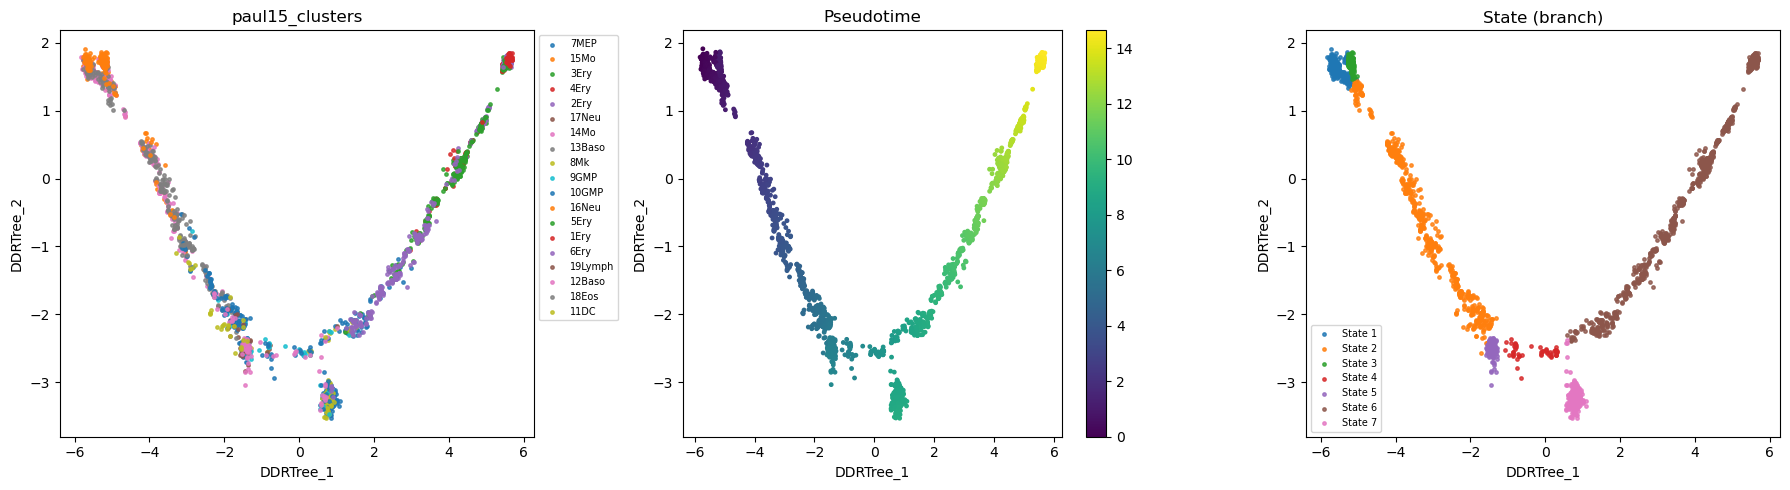

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

emb = adata.obsm['X_DDRTree']
# Panel 1: original cluster annotation
clusters = adata.obs['paul15_clusters'].astype(str)
for lab in clusters.unique():
    m = clusters == lab
    axes[0].scatter(emb[m, 0], emb[m, 1], s=6, label=lab, alpha=0.8)
axes[0].legend(fontsize=7, bbox_to_anchor=(1, 1), loc='upper left')
axes[0].set_title('paul15_clusters')

# Panel 2: pseudotime
sc1 = axes[1].scatter(emb[:, 0], emb[:, 1], c=adata.obs['Pseudotime'],
                       s=6, cmap='viridis')
plt.colorbar(sc1, ax=axes[1]); axes[1].set_title('Pseudotime')

# Panel 3: state
states = adata.obs['State'].astype(str)
for lab in sorted(states.unique()):
    m = states == lab
    axes[2].scatter(emb[m, 0], emb[m, 1], s=6, label=f'State {lab}', alpha=0.8)
axes[2].legend(fontsize=7); axes[2].set_title('State (branch)')

for ax in axes:
    ax.set_xlabel('DDRTree_1'); ax.set_ylabel('DDRTree_2')
plt.tight_layout(); plt.show()

## 5. Branch-point differential expression (BEAM)

In [5]:
bps = mono.branch_points
print(f'branch points: {bps}')
if bps:
    try:
        beam = mono.BEAM(branch_point=1, cores=1)
        top = beam[beam['status'] == 'OK'].sort_values('qval').head(15)
        print('Top-15 BEAM genes at branch 1:')
        print(top[['pval', 'qval']])
    except ValueError as e:
        print('BEAM skipped:', e)

branch points: ['Y_47', 'Y_89', 'Y_167']


Top-15 BEAM genes at branch 1:
          pval  qval
Ncapg2     0.0   0.0
Itgb5      0.0   0.0
Itgb1      0.0   0.0
Nags       0.0   0.0
Naa50      0.0   0.0
Arhgdig    0.0   0.0
Arhgap32   0.0   0.0
Ndufc2     0.0   0.0
Ndufb8     0.0   0.0
Ndufa7     0.0   0.0
Mrpl18     0.0   0.0
Myo10      0.0   0.0
Mthfd1     0.0   0.0
Mtdh       0.0   0.0
Itm2b      0.0   0.0


## Summary

Everything you just computed is now living inside `adata` — `obs.Pseudotime`,
`obs.State`, `obsm.X_DDRTree`, `uns.monocle` (principal graph centres, MST,
branch points). You can pickle/save the AnnData and reload into downstream
scanpy tools without re-running.

For side-by-side timing and accuracy comparison against R Monocle 2, see
`benchmark_vs_R.ipynb`.